# Inference & Testing Model

In [1]:
!pip install tensorflow gensim scikit-learn pandas numpy -q
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.2 MB/s eta 0:00:00


In [2]:
import numpy as np, pandas as pd
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import re, warnings; warnings.filterwarnings('ignore')

LABEL_NAMES  = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}
LABEL_COLORS = {0: '\033[91m', 1: '\033[93m', 2: '\033[92m'}
RESET        = '\033[0m'
MAX_SEQ_LEN  = 100

print("Library berhasil diimport")

Library berhasil diimport


In [3]:
factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()
factory_sw = StopWordRemoverFactory()
stop_word_remover = factory_sw.create_stop_word_remover()

EXTRA_STOPWORDS = {
    'yg','yang','dgn','dengan','di','ke','nya','aja',
    'gak','ga','udah','udh','lg','lagi','tp','tapi',
    'klo','kalau','klu','kak','min','bang','mas','mba',
    'bgt','banget','deh','sih','nih','loh','dong',
    'jg','juga','sdh','sudah','blm','belum','gt','gitu'
}

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[@#]\w+', ' ', text)
    text = re.sub(r'[\U00010000-\U0010ffff]', ' ', text, flags=re.UNICODE)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = stop_word_remover.remove(text)
    tokens = [w for w in text.split() if w not in EXTRA_STOPWORDS and len(w) > 2]
    text = ' '.join(tokens)
    text = stemmer.stem(text)
    return text

print("Fungsi preprocessing siap")
print(f"\nContoh preprocessing:")
test_input = "Aplikasi ini sangat bagus dan membantu sekali!"
print(f"Input  : '{test_input}'")
print(f"Output : '{preprocess_text(test_input)}'")

Fungsi preprocessing siap

Contoh preprocessing:
Input  : 'Aplikasi ini sangat bagus dan membantu sekali!'
Output : 'aplikasi sangat bagus bantu sekali'


In [4]:
models_info = {}

try:
    import pickle as pkl
    with open('models/scheme1/tfidf_vectorizer.pkl', 'rb') as f:
        tok_s1 = pkl.load(f)
    model_s1 = load_model('models/scheme1/best_model.keras')
    models_info['Skenario 1 (LSTM + TF-IDF)'] = {
        'model': model_s1, 'type': 'sequence', 'tokenizer': tok_s1
    }
    print("Skenario 1 berhasil dimuat")
except Exception as e:
    print(f"Skenario 1 tidak tersedia: {e}")

try:
    with open('models/scheme2/tokenizer.pkl', 'rb') as f:
        tok_s2 = pkl.load(f)
    model_s2 = load_model('models/scheme2/best_model.keras')
    models_info['Skenario 2 (BiLSTM + Word2Vec)'] = {
        'model': model_s2, 'type': 'sequence', 'tokenizer': tok_s2
    }
    print("Skenario 2 berhasil dimuat")
except Exception as e:
    print(f"Skenario 2 tidak tersedia: {e}")

try:
    with open('models/scheme3/tokenizer.pkl', 'rb') as f:
        tok_s3 = pkl.load(f)
    model_s3 = load_model('models/scheme3/best_model.keras')
    models_info['Skenario 3 (CNN-LSTM + Embedding)'] = {
        'model': model_s3, 'type': 'sequence', 'tokenizer': tok_s3
    }
    print("Skenario 3 berhasil dimuat")
except Exception as e:
    print(f"Skenario 3 tidak tersedia: {e}")

print(f"\nTotal model dimuat: {len(models_info)}")

Skenario 1 berhasil dimuat
Skenario 2 berhasil dimuat
Skenario 3 berhasil dimuat

Total model dimuat: 3


In [5]:
def predict_sentiment(text, model_key='Skenario 3 (CNN-LSTM + Embedding)'):
    if model_key not in models_info:
        print(f"Model '{model_key}' tidak tersedia")
        return None

    info    = models_info[model_key]
    cleaned = preprocess_text(text)

    tok = info['tokenizer']
    seq = tok.texts_to_sequences([cleaned])
    X   = pad_sequences(seq, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

    proba    = info['model'].predict(X, verbose=0)[0]
    pred_idx = np.argmax(proba)

    return {
        'text'         : text,
        'cleaned'      : cleaned,
        'prediction'   : LABEL_NAMES[pred_idx],
        'confidence'   : float(proba[pred_idx]),
        'probabilities': {
            'Negatif': float(proba[0]),
            'Netral' : float(proba[1]),
            'Positif': float(proba[2])
        }
    }

def predict_all_schemes(text):
    print(f"Teks Input  : \"{text}\"")
    for model_key in models_info:
        result = predict_sentiment(text, model_key)
        if result:
            color = LABEL_COLORS[list(LABEL_NAMES.values()).index(result['prediction'])]
            print(f"  {model_key:<35} : {color}{result['prediction']:<8}{RESET}"
                  f"  (confidence: {result['confidence']*100:.1f}%)")

print("Fungsi prediksi siap")

Fungsi prediksi siap


In [6]:
print("INFERENCE — CONTOH DATA BARU")

test_texts = [
    # POSITIF
    "Aplikasi ini sangat bagus! Mudah digunakan dan transaksi cepat. Terima kasih!",
    "Sangat puas dengan pelayanan driver yang ramah dan tepat waktu. Recommended!",
    "Fitur barunya keren banget, loading lebih cepat dari sebelumnya. Top!",

    # NETRAL
    "Lumayan sih aplikasinya, ada beberapa fitur yang bisa diperbaiki.",
    "Sudah cukup baik tapi masih ada bug kecil. Semoga terus ditingkatkan.",
    "Biasa aja, tidak ada yang istimewa tapi tidak mengecewakan juga.",

    # NEGATIF
    "Aplikasi sering crash dan tidak bisa dibuka. Sangat mengecewakan!",
    "Pelayanan buruk sekali! Sudah 3 hari order tidak sampai dan CS tidak respon.",
    "Aplikasi lambat banget, baterai cepat habis. Mending hapus aja.",
]

for text in test_texts:
    predict_all_schemes(text)

INFERENCE — CONTOH DATA BARU
Teks Input  : "Aplikasi ini sangat bagus! Mudah digunakan dan transaksi cepat. Terima kasih!"
  Skenario 1 (LSTM + TF-IDF)          : Positif   (confidence: 99.7%)
  Skenario 2 (BiLSTM + Word2Vec)      : Positif   (confidence: 99.4%)
  Skenario 3 (CNN-LSTM + Embedding)   : Positif   (confidence: 100.0%)
Teks Input  : "Sangat puas dengan pelayanan driver yang ramah dan tepat waktu. Recommended!"
  Skenario 1 (LSTM + TF-IDF)          : Positif   (confidence: 100.0%)
  Skenario 2 (BiLSTM + Word2Vec)      : Positif   (confidence: 99.5%)
  Skenario 3 (CNN-LSTM + Embedding)   : Positif   (confidence: 100.0%)
Teks Input  : "Fitur barunya keren banget, loading lebih cepat dari sebelumnya. Top!"
  Skenario 1 (LSTM + TF-IDF)          : Positif   (confidence: 99.7%)
  Skenario 2 (BiLSTM + Word2Vec)      : Positif   (confidence: 99.0%)
  Skenario 3 (CNN-LSTM + Embedding)   : Positif   (confidence: 100.0%)
Teks Input  : "Lumayan sih aplikasinya, ada beberapa fitur yang 

In [7]:
# KALIMAT BEBAS
custom_texts = [
    "Fitur COD nya hilang padahal sering saya pakai",
    "Promo cashback hari ini lumayan lah, biasa saja",
    "Wah mantap sekali! Pengiriman super cepat dan aman",
]

print("\nINFERENCE — KALIMAT KUSTOM")
for text in custom_texts:
    predict_all_schemes(text)


INFERENCE — KALIMAT KUSTOM
Teks Input  : "Fitur COD nya hilang padahal sering saya pakai"
  Skenario 1 (LSTM + TF-IDF)          : Negatif   (confidence: 99.6%)
  Skenario 2 (BiLSTM + Word2Vec)      : Negatif   (confidence: 72.4%)
  Skenario 3 (CNN-LSTM + Embedding)   : Negatif   (confidence: 100.0%)
Teks Input  : "Promo cashback hari ini lumayan lah, biasa saja"
  Skenario 1 (LSTM + TF-IDF)          : Positif   (confidence: 74.7%)
  Skenario 2 (BiLSTM + Word2Vec)      : Negatif   (confidence: 81.9%)
  Skenario 3 (CNN-LSTM + Embedding)   : Positif   (confidence: 100.0%)
Teks Input  : "Wah mantap sekali! Pengiriman super cepat dan aman"
  Skenario 1 (LSTM + TF-IDF)          : Positif   (confidence: 100.0%)
  Skenario 2 (BiLSTM + Word2Vec)      : Positif   (confidence: 99.5%)
  Skenario 3 (CNN-LSTM + Embedding)   : Positif   (confidence: 100.0%)


In [8]:
# BATCH PREDIKSI
def batch_predict(texts, model_key=None):
    if model_key is None:
        model_key = list(models_info.keys())[-1]

    results = []
    for text in texts:
        r = predict_sentiment(text, model_key)
        if r:
            results.append({
                'Teks'      : text[:60] + '...' if len(text) > 60 else text,
                'Prediksi'  : r['prediction'],
                'Confidence': f"{r['confidence']*100:.1f}%",
                'P(Negatif)': f"{r['probabilities']['Negatif']*100:.1f}%",
                'P(Netral)' : f"{r['probabilities']['Netral']*100:.1f}%",
                'P(Positif)': f"{r['probabilities']['Positif']*100:.1f}%",
            })

    df_result = pd.DataFrame(results)
    return df_result

# Jalankan batch inference
all_test = test_texts + custom_texts
df_inference = batch_predict(all_test)

print("\nHASIL BATCH INFERENCE:")
print(df_inference.to_string(index=False))
print(f"\nDistribusi Prediksi:")
print(df_inference['Prediksi'].value_counts())

df_inference.to_csv('reports/inference_results.csv', index=False, encoding='utf-8-sig')
print("\nHasil inference tersimpan: reports/inference_results.csv")


HASIL BATCH INFERENCE:
                                                           Teks Prediksi Confidence P(Negatif) P(Netral) P(Positif)
Aplikasi ini sangat bagus! Mudah digunakan dan transaksi cep...  Positif     100.0%       0.0%      0.0%     100.0%
Sangat puas dengan pelayanan driver yang ramah dan tepat wak...  Positif     100.0%       0.0%      0.0%     100.0%
Fitur barunya keren banget, loading lebih cepat dari sebelum...  Positif     100.0%       0.0%      0.0%     100.0%
Lumayan sih aplikasinya, ada beberapa fitur yang bisa diperb...  Positif      99.9%       0.0%      0.1%      99.9%
Sudah cukup baik tapi masih ada bug kecil. Semoga terus diti...  Positif      92.8%       6.0%      1.3%      92.8%
Biasa aja, tidak ada yang istimewa tapi tidak mengecewakan j...  Negatif      99.7%      99.7%      0.0%       0.3%
Aplikasi sering crash dan tidak bisa dibuka. Sangat mengecew...  Negatif      97.3%      97.3%      0.3%       2.4%
Pelayanan buruk sekali! Sudah 3 hari order tidak

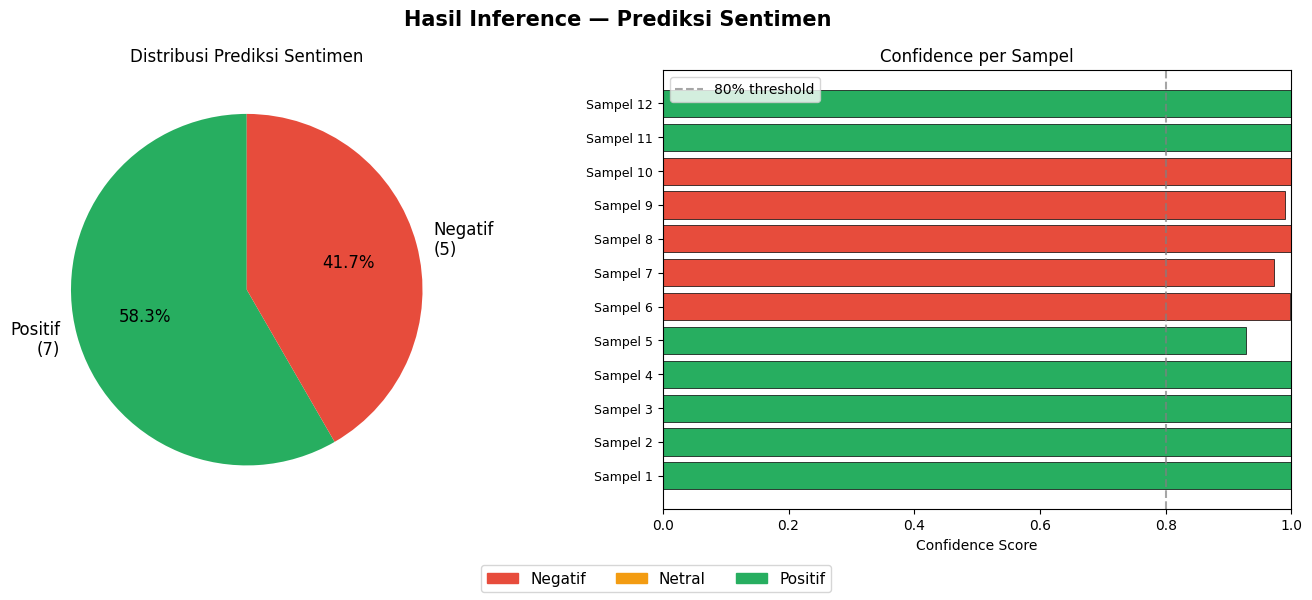

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Hasil Inference — Prediksi Sentimen', fontsize=15, fontweight='bold')

# Distribusi prediksi
colors_map = {'Negatif':'#e74c3c', 'Netral':'#f39c12', 'Positif':'#27ae60'}
pred_counts = df_inference['Prediksi'].value_counts()
axes[0].pie(pred_counts.values,
            labels=[f"{k}\n({v})" for k, v in pred_counts.items()],
            colors=[colors_map.get(k, 'gray') for k in pred_counts.index],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize':12})
axes[0].set_title('Distribusi Prediksi Sentimen')

# Confidence per sampel
confs = [float(c.strip('%'))/100 for c in df_inference['Confidence']]
preds = df_inference['Prediksi'].tolist()
bar_colors = [colors_map.get(p, 'gray') for p in preds]
y_pos = range(len(confs))
axes[1].barh(y_pos, confs, color=bar_colors, edgecolor='black', linewidth=0.5)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([f"Sampel {i+1}" for i in y_pos], fontsize=9)
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Confidence Score')
axes[1].set_title('Confidence per Sampel')
axes[1].axvline(0.8, color='gray', linestyle='--', alpha=0.7, label='80% threshold')
axes[1].legend()

patches = [mpatches.Patch(color=v, label=k) for k, v in colors_map.items()]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=11)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [10]:
def interactive_predict(text, model_key=None):
    if model_key is None:
        model_key = list(models_info.keys())[-1]

    result = predict_sentiment(text, model_key)
    if result is None:
        return 'Error: Model tidak tersedia'

    print(f"\n{'-'*50}")
    print(f"Input     : {result['text']}")
    print(f"Cleaned   : {result['cleaned']}")
    print(f"Model     : {model_key}")
    print(f"----------------------------------")
    print(f"Probabilitas:")
    for label, prob in result['probabilities'].items():
        bar = '█' * int(prob * 20)
        print(f"   {label:<8} : {bar:<20} {prob*100:5.1f}%")
    print(f"----------------------------------")
    print(f"Prediksi  : {result['prediction'].upper()}")
    print(f"Confidence: {result['confidence']*100:.1f}%")
    print(f"{'-'*50}")

    return result['prediction']

print("DEMO INFERENCE")

demo_texts = [
    "Aplikasi ini membantu sekali dalam keseharian saya, top banget!",
    "Sering error dan tidak bisa login. Sangat mengecewakan.",
    "Biasa saja, standar seperti aplikasi lain pada umumnya."
]
for text in demo_texts:
    label = interactive_predict(text)
    print(f"Output Kategorikal: '{label}'\n")


DEMO INFERENCE

--------------------------------------------------
Input     : Aplikasi ini membantu sekali dalam keseharian saya, top banget!
Cleaned   : aplikasi bantu sekali hari top
Model     : Skenario 3 (CNN-LSTM + Embedding)
----------------------------------
Probabilitas:
   Negatif  :                        0.0%
   Netral   :                        0.0%
   Positif  : ███████████████████  100.0%
----------------------------------
Prediksi  : POSITIF
Confidence: 100.0%
--------------------------------------------------
Output Kategorikal: 'Positif'


--------------------------------------------------
Input     : Sering error dan tidak bisa login. Sangat mengecewakan.
Cleaned   : sering error tidak login sangat kecewa
Model     : Skenario 3 (CNN-LSTM + Embedding)
----------------------------------
Probabilitas:
   Negatif  : ███████████████████  100.0%
   Netral   :                        0.0%
   Positif  :                        0.0%
----------------------------------
Prediksi  